In [1]:
# Import Libraries
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint
from scipy.stats import uniform

from sklearn.model_selection import (
    GridSearchCV,RandomizedSearchCV,
    learning_curve,cross_val_score)

from sklearn.metrics import (
    mean_absolute_error,mean_squared_error,r2_score)
from sklearn.inspection import permutation_importance

import shap
print("Imported successfully")

Imported successfully


In [2]:
# Load Training Data
X_train = joblib.load("../models/preprocessing/X_train.pkl")
X_test = joblib.load("../models/preprocessing/X_test.pkl")

y_train = joblib.load("../models/preprocessing/y_train.pkl")
y_test = joblib.load("../models/preprocessing/y_test.pkl")

In [3]:
# Load Best Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(random_state=42)
dt = DecisionTreeRegressor(random_state=42)

In [4]:
# 1. GridSearchCV
rf_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]}

In [5]:
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=rf_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=2)
grid_rf.fit(X_train,y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2', verbose=2)

In [6]:
print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
0.711147915259837


In [7]:
# 2.RandomizedSearchCV
gb_random = {
    "learning_rate":uniform(0.01,0.3),
    "n_estimators":randint(50,500),
    "max_depth":randint(2,10),
    "subsample":uniform(0.6,0.4)
}

In [8]:
random_gb = RandomizedSearchCV(
    gb,
    gb_random,
    n_iter=30,
    cv=5,
    random_state=42,
    scoring="r2",
    n_jobs=-1)
random_gb.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000015B3DFE6120>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000015B3DFB56D0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000015B3DFE6270>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000015B3DFB6AD0>},
                   random_state=42, scoring='r2')

In [9]:
print(random_gb.best_params_)

{'learning_rate': np.float64(0.22205720315428515), 'max_depth': 4, 'n_estimators': 468, 'subsample': np.float64(0.9085081386743783)}


In [10]:
# Cross Validation
cv_score = cross_val_score(
    grid_rf.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring="r2")
print(cv_score)
print(cv_score.mean())

[0.74533009 0.7076966  0.74083502 0.69712712 0.66475075]
0.711147915259837


In [11]:
# Learning Curve
train_sizes, train_scores, validation_scores = learning_curve(
    grid_rf.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1,1.0,10),
    n_jobs=-1)

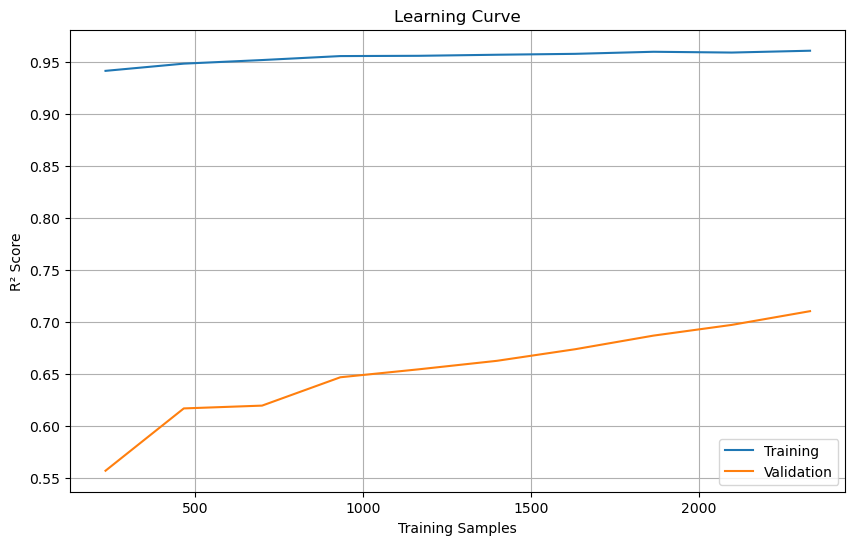

In [12]:
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)
plt.figure(figsize=(10,6))
plt.plot(train_sizes,train_mean,label="Training")
plt.plot(train_sizes,validation_mean,label="Validation")
plt.xlabel("Training Samples")
plt.ylabel("R² Score")
plt.title("Learning Curve")
plt.legend()
plt.grid()
plt.savefig("../outputs/figures/learning_curve.png",dpi=300)
plt.show()

In [13]:
# Final Prediction
best_model = grid_rf.best_estimator_
prediction = best_model.predict(X_test)

In [14]:
# Residual Error Analysis
residuals = y_test-prediction

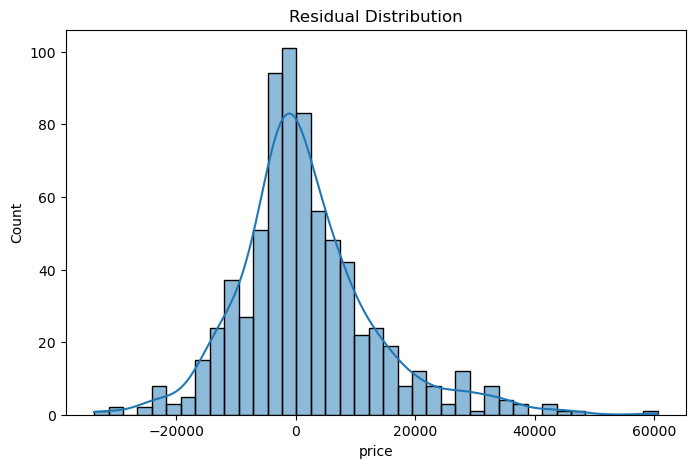

In [15]:
# Histogram
plt.figure(figsize=(8,5))
sns.histplot(residuals,kde=True)
plt.title("Residual Distribution")
plt.savefig("../outputs/figures/residual_distribution.png",dpi=300)
plt.show()

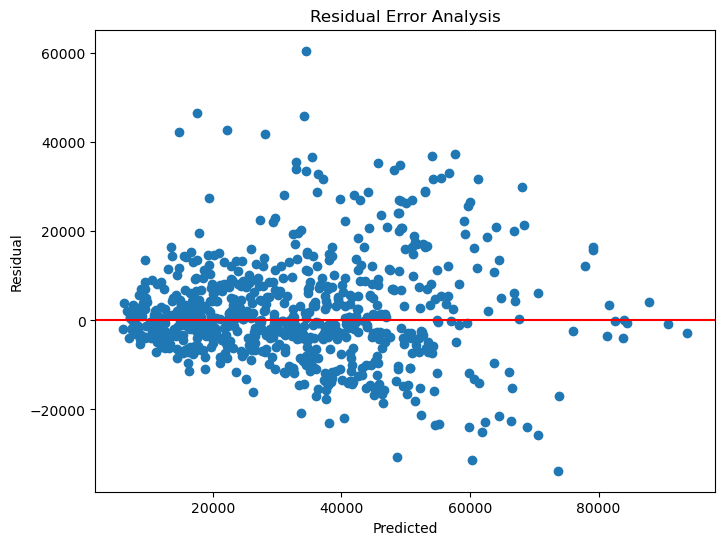

In [16]:
# Residual Plot
plt.figure(figsize=(8,6))
plt.scatter(prediction,residuals)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Error Analysis")
plt.savefig("../outputs/figures/residual_plot.png",dpi=300)
plt.show()

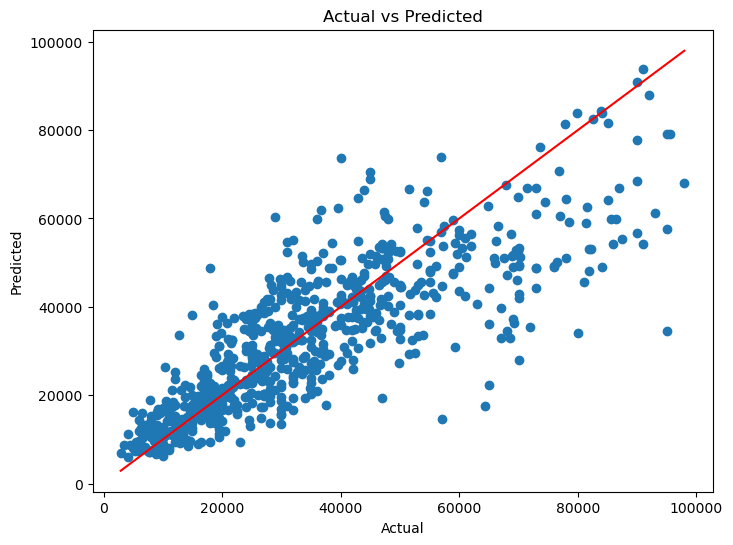

In [17]:
# Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test,prediction)
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color="red")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.savefig("../outputs/figures/actual_vs_predicted.png",dpi=300)
plt.show()

In [19]:
import joblib

preprocessor = joblib.load("../models/preprocessing/preprocessor.pkl")
# Get feature names from the fitted preprocessor
feature_names = preprocessor.get_feature_names_out()
# Save feature names
joblib.dump(
    feature_names,
    "../models/metadata/feature_names.pkl"
)

print("feature_names.pkl saved successfully!")

feature_names.pkl saved successfully!


In [20]:
importance = pd.DataFrame({
    "Feature":feature_names,
    "Importance":best_model.feature_importances_})
importance = importance.sort_values(
    "Importance",ascending=False).head(20)

In [21]:
importance = pd.DataFrame({
    "Feature":feature_names,
    "Importance":best_model.feature_importances_})
importance = importance.sort_values(
    "Importance",ascending=False).head(20)

SHAP values computed successfully!


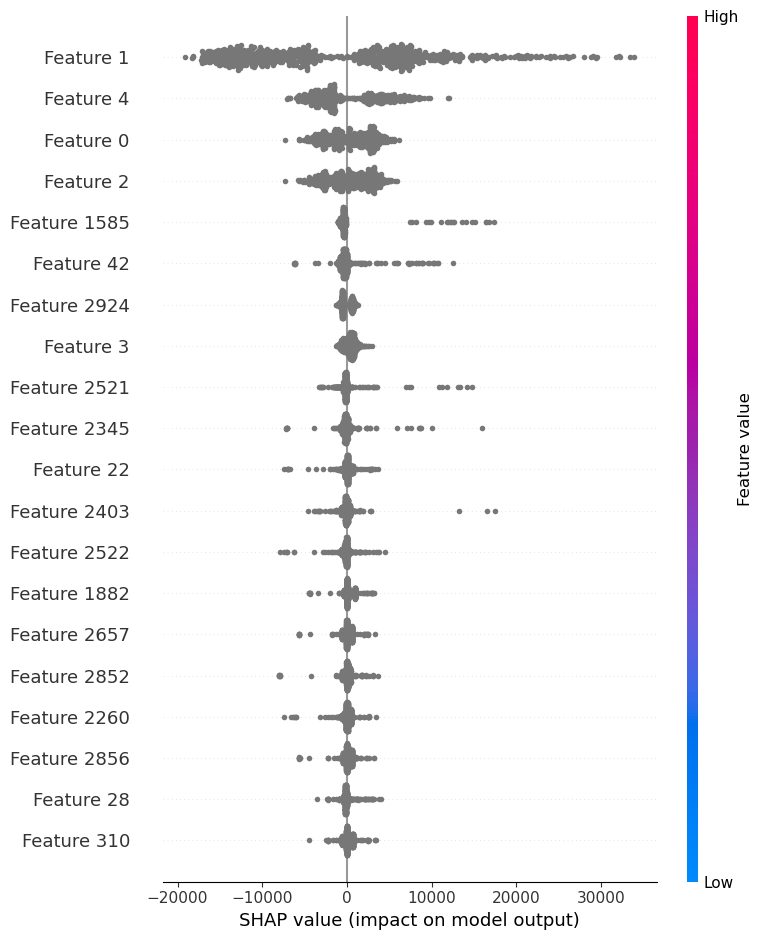

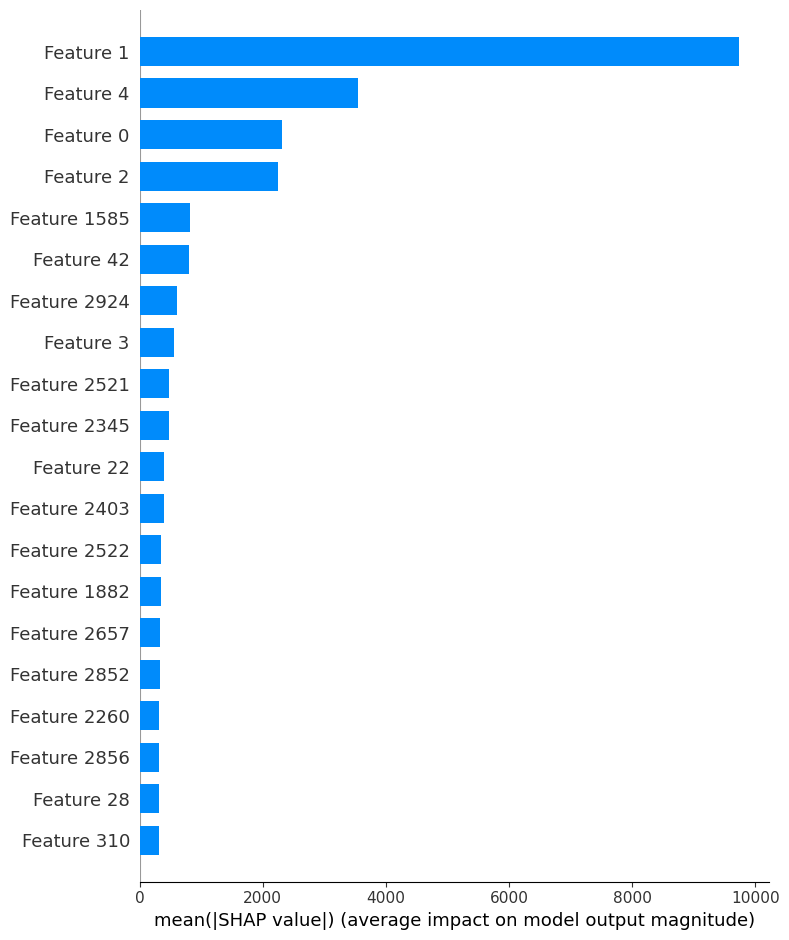

['../models/model_metadata.pkl']

In [39]:
import shap

# Convert sparse matrix to dense NumPy array
X_test_dense = X_test.toarray()

# Create TreeExplainer
explainer = shap.TreeExplainer(best_model)

# Disable the additivity check
shap_values = explainer.shap_values(
    X_test_dense,
    check_additivity=False
)

print("SHAP values computed successfully!")

shap.summary_plot(shap_values,X_test,show=False)
plt.savefig("../outputs/figures/shap_summary.png",dpi=300)
plt.show()

shap.summary_plot(shap_values,X_test,plot_type="bar",show=False)
plt.savefig("../outputs/figures/shap_bar.png",dpi=300)
plt.show()

joblib.dump(best_model,"../models/best_model.pkl")

metadata = {
    "Best Model":"Random Forest",
    "R2":r2_score(y_test,prediction),
    "MAE":mean_absolute_error(y_test,prediction),
    "RMSE":np.sqrt(mean_squared_error(y_test,prediction))}
joblib.dump(metadata,"../models/model_metadata.pkl")

    outputs/
    │
    ├── figures/
    │   ├── learning_curve.png
    │   ├── residual_distribution.png
    │   ├── residual_plot.png
    │   ├── actual_vs_predicted.png
    │   ├── feature_importance.png
    │   ├── shap_summary.png
    │   └── shap_bar.png
    │
    models/
    │
    ├── best_model.pkl
    ├── model_metadata.pkl